La deserción escolar es una problemática relevante en los sistemas educativos, ya que impacta directamente en las oportunidades de desarrollo personal y profesional de los estudiantes.

El presente proyecto tiene como objetivo analizar los factores asociados a la deserción escolar en un conjunto de datos educativos, utilizando herramientas de análisis de datos en Python.

A través del procesamiento, limpieza y exploración de los datos, se busca identificar patrones y variables que influyen en la permanencia o abandono de los estudiantes, con el fin de aportar información útil para la toma de decisiones en contextos educativos.

Este análisis se enmarca en mi experiencia como docente, lo que permite interpretar los resultados desde una perspectiva pedagógica.

Cabe aclarar que los datos los recolecté personalmente a través de encuestas.

#Carga y análisis de datos

In [ ]:
#Cargo las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
import io

In [ ]:
#Cargo la base de datos
from google.colab import files
uploaded = files.upload()


Saving Encuesta EPJA.xlsx to Encuesta EPJA.xlsx


In [ ]:
#La llamo datos
datos = pd.read_excel(io.BytesIO(uploaded['Encuesta EPJA.xlsx']))
datos.head()

,Fecha de nacimiento,Género,"¿En qué año abandonaste el secundario común? En caso de no haberlo comenzado, ¿en qué año terminasté la primaria?","Antes de Epja, ¿Cuál fue la última escuela a la cuál asististe?",¿Era de nivel primario o secundario?,¿En qué ciudad o pueblo queda?,¿Qué año escolar estabas cursando cuando abandonaste el secundario común?,¿Cuál fue el motivo por el cual abandonaste o no empezaste el secundario común?,¿Por qué decidiste volver a cursar el secundario?
0,2003-08-13,Masculino,2018,784,Secundario,Trelew,1º año,Por desinterés,Necesito el título para el trabajo
1,1986-08-05,Prefiero no decirlo,2023,NaN,Primario,NaN,No empecé el secundario,SIn especificar,Necesito el título para el trabajo
2,2007-03-08,Masculino,2024,714,Secundario,Trelew,5º año,Me echaron,Necesito el título para el trabajo
3,2004-05-16,Masculino,2018,712,Secundario,Trelew,2º año,Por tener que trabajar,Porque quiero seguir estudiando
4,2005-10-31,Masculino,2021,762,Secundario,Trelew,3º año,Por pandemia,Por interés personal


In [ ]:
#Veo cuántas filas y columnas tiene
datos.shape

(170, 9)

In [ ]:
#Cuántas filas tiene al menos un valor nulo
num_filas_nulas = datos.isnull().any(axis=1).sum()
print(f"Filas con al menos un valor nulo: {num_filas_nulas}")


Filas con al menos un valor nulo: 25


In [ ]:
# Contar valores nulos hay por columna
nulos_por_columna = datos.isnull().sum()

print(nulos_por_columna)


Fecha de nacimiento                                                                                                   0
Género                                                                                                                0
¿En qué año abandonaste el secundario común? En caso de no haberlo comenzado, ¿en qué año terminasté la primaria?     0
Antes de Epja, ¿Cuál fue la última escuela a la cuál asististe?                                                      22
¿Era de nivel primario o secundario?                                                                                  4
¿En qué ciudad o pueblo queda?                                                                                        5
¿Qué año escolar estabas cursando cuando abandonaste el secundario común?                                             0
¿Cuál fue el motivo por el cual abandonaste o no empezaste el secundario común?                                       0
¿Por qué decidiste volver a cursar el se

La columna que más valores nulos tiene es la que responde a: Antes de Epja, ¿Cuál fue la última escuela a la cuál asististe?

Considerendo la cantidad de respuesta, los valores nulos son menores al 13%



In [ ]:
# Convierto la fecha de nacieminto en EDAD
from datetime import date

datos["Fecha de nacimiento"] = pd.to_datetime(datos["Fecha de nacimiento"], errors="coerce")

# Calcular la edad
hoy = date.today()
datos["Fecha de nacimiento"] = datos["Fecha de nacimiento"].apply(
    lambda fecha: hoy.year - fecha.year - ((hoy.month, hoy.day) < (fecha.month, fecha.day))
)

# Ahora la columna "Fecha de nacimiento" tiene la edad
print(datos.head())


   Fecha de nacimiento               Género  \
0                   22            Masculino   
1                   39  Prefiero no decirlo   
2                   18            Masculino   
3                   21            Masculino   
4                   19            Masculino   

   ¿En qué año abandonaste el secundario común? En caso de no haberlo comenzado, ¿en qué año terminasté la primaria?  \
0                                               2018                                                                   
1                                               2023                                                                   
2                                               2024                                                                   
3                                               2018                                                                   
4                                               2021                                                                 

In [ ]:
# Modifico los encabezados de la tabla para que sea más práctico a la hora de trabajar con ellos.
# Diccionario: encabezado actual → encabezado nuevo
nuevos_encabezados = {
    "Fecha de nacimiento" : "Edad",
    "¿En qué año abandonaste el secundario común? En caso de no haberlo comenzado, ¿en qué año terminasté la primaria?":"Año de abandono",
    "Antes de Epja, ¿Cuál fue la última escuela a la cuál asististe?":"Última escuela común",
    "¿Era de nivel primario o secundario?":"Nivel",
    "¿En qué ciudad o pueblo queda?":"Ciudad",
    "¿Qué año escolar estabas cursando cuando abandonaste el secundario común?":"Año escolar de abandono",
    "¿Cuál fue el motivo por el cual abandonaste o no empezaste el secundario común?":"Motivo de abandono",
    "¿Por qué decidiste volver a cursar el secundario?":"Motivo para seguir estudiando"
}

# Renombrar columnas
datos = datos.rename(columns=nuevos_encabezados)

# Guardar archivo actualizado
datos.to_csv("archivo_con_encabezados_actualizados.csv", index=False)

print("Encabezados actualizados y archivo guardado correctamente.")


Encabezados actualizados y archivo guardado correctamente.


In [ ]:
datos.head(10)

,Edad,Género,Año de abandono,Última escuela común,Nivel,Ciudad,Año escolar de abandono,Motivo de abandono,Motivo para seguir estudiando
0,22,Masculino,2018,784,Secundario,Trelew,1º año,Por desinterés,Necesito el título para el trabajo
1,39,Prefiero no decirlo,2023,NaN,Primario,NaN,No empecé el secundario,SIn especificar,Necesito el título para el trabajo
2,18,Masculino,2024,714,Secundario,Trelew,5º año,Me echaron,Necesito el título para el trabajo
3,21,Masculino,2018,712,Secundario,Trelew,2º año,Por tener que trabajar,Porque quiero seguir estudiando
4,19,Masculino,2021,762,Secundario,Trelew,3º año,Por pandemia,Por interés personal
5,42,Femenino,1999,122,Primario,Trelew,No empecé el secundario,Fui mamá adolescente,Necesito el título para el trabajo
6,5,Masculino,2014,792,Secundario,Trelew,1º año,Por desinterés,Porque quiero seguir estudiando
7,24,Femenino,0,744,Secundario,Trelew,1º año,Problemas de salud mental,Necesito el título para el trabajo
8,55,Masculino,1990,784,Secundario,Trelew,3º año,Por tener que trabajar,Por mi familia
9,21,Masculino,2021,787,Secundario,Trelew,2º año,Por pandemia,Porque quiero seguir estudiando


In [ ]:
# Veo los valores únicos de la columna
valores_unicos = datos["Motivo de abandono"].unique()
print(valores_unicos)

# Cuento cuántas veces aparece cada uno
conteo = datos["Motivo de abandono"].value_counts()
print(conteo)


['Por desinterés' 'SIn especificar' 'Me echaron' 'Por tener que trabajar'
 'Por pandemia' 'Fui mamá adolescente' 'Problemas de salud mental'
 'Problemas personales' 'Por enojo porque quemaron mis papeles'
 'Muchas faltas y no entendia' 'Sobreedad '
 'No me querían ayudar en la escuela' 'Por repitencia'
 'Por acosos, peleas o bullying' 'Por enfermedad propia'
 'Para cuidar a un familiar' 'Depresión' 'Sin especificar '
 'Sin especificar' 'No abandoné ' 'Porque fui mamá'
 'Por estar dedicada al deporte' 'Embarazo' 'Cambio de provincia '
 'Por expulsión por mal comportamiento' 'Problemas familiares '
 'Problemas personales ' 'Inasistencia ' 'Por adicción'
 'Por no tener acceso a una escuela' 'Por mis hijos'
 'Me fui de la provincia ' 'Quedé embarazada' 'Por cuestiones personales '
 'Fui mamá ' 'Por inasistencia ' 'Temas familiares'
 'Fallecimiento de mi madre ' 'No adaptarme a la virtualidad'
 'Terminé pero debía materias ' 'Ejército'
 'Por pandemia y no tener acceso a una computadora']
Mo

In [ ]:
# Agrupo los valores
# Diccionario de agrupación
mapeo = {
    "Por enfermedad propia": "Por enfermedad propia",
    "Problemas de salud mental": "Por enfermedad propia",
    "Depresión": "Por enfermedad propia",
    "Me echaron": "Por expulsión por mal comportamiento",
    "Fui mamá": "Por embarazo",
    "Embarazo": "Por embarazo",
    "Quedé embarazada": "Por embarazo",
    "Porque fui mamá":"Por embarazo",
    "Por mis hijos":"Por embarazo",
    "Fui mamá adolescente":"Por embarazo",
    "Por repitencia":"Repitencia",
    "Sobreedad":"Repitencia",
    "Por inasistencia":"Inasistencia",
    "Muchas faltas y no entendia":"Inasistencia",
    "Sin especificar":"Otros",
    "Por cuestiones personales":"Otros",
    "Por estar dedicada al deporte":"Otros",
    "No me querían ayudar en la escuela":"Otros",
    "Temas familiares":"Cuestiones familiares",
    "Problemas familiares":"Cuestiones familiares",
    "Problemas personales":"Cuestiones familiares",
    "Fallecimiento de mi madre":"Cuestiones familiares",
    "Para cuidar a un familiar":"Cuestiones familiares",
    "Cambio de provincia":"Otros",
    "Me fui de la provincia":"Otros",
    "Por no tener acceso a una escuela":"Otros",
    "Terminé pero debía materias":"Otros",
    "Ejército":"Otros",
    "SIn especificar":"Otros",
    "Por enojo porque quemaron mis papeles":"Otros",
    "No abandoné":"Otros",
    "Por pandemia":"Por pandemia",
    "Por pandemia y no tener acceso a una computadora":"Por pandemia",
    "No adaptarme a la virtualidad":"Por pandemia"

}
# Elimino los espacios al inicio y final
datos["Motivo de abandono"] = datos["Motivo de abandono"].str.strip()

# Reemplazo según mapeo
datos["Motivo de abandono"] = datos["Motivo de abandono"].replace(mapeo)

# Veo resultados agrupados
print(datos["Motivo de abandono"].value_counts())


Motivo de abandono
Por tener que trabajar                  52
Por desinterés                          39
Otros                                   19
Cuestiones familiares                   13
Por embarazo                             9
Por enfermedad propia                    8
Por acosos, peleas o bullying            8
Por expulsión por mal comportamiento     6
Por pandemia                             5
Por adicción                             5
Repitencia                               3
Inasistencia                             3
Name: count, dtype: int64


In [ ]:
# Veo valores únicos de la columna
valores_unicos = datos["Motivo para seguir estudiando"].unique()
print(valores_unicos)

# Cuento cuántas veces aparece cada uno
conteo = datos["Motivo para seguir estudiando"].value_counts()
print(conteo)

['Necesito el título para el trabajo' 'Porque quiero seguir estudiando'
 'Por interés personal' 'Por mi familia'
 'Por obligación familiar, para conseguir un trabajo'
 'Es mi momento después de 54 años']
Motivo para seguir estudiando
Necesito el título para el trabajo                    66
Porque quiero seguir estudiando                       54
Por interés personal                                  36
Por mi familia                                        11
Por obligación familiar, para conseguir un trabajo     2
Es mi momento después de 54 años                       1
Name: count, dtype: int64


In [ ]:
# Diccionario de agrupación
mapeo = {
    "Por obligación familiar, para conseguir un trabajo": "Necesito el título para el trabajo",
    "Es mi momento después de 54 años": "Por interés personal"
}
# Elimino espacios al inicio y final
datos["Motivo para seguir estudiando"] = datos["Motivo para seguir estudiando"].str.strip()

# Reemplazo según mapeo
datos["Motivo para seguir estudiando"] = datos["Motivo para seguir estudiando"].replace(mapeo)

# Veo resultados agrupados
print(datos["Motivo para seguir estudiando"].value_counts())

Motivo para seguir estudiando
Necesito el título para el trabajo    68
Porque quiero seguir estudiando       54
Por interés personal                  37
Por mi familia                        11
Name: count, dtype: int64


In [ ]:
# Guardo las modificaciones hechas en una nueva base de dato
datos.to_excel("Encuesta EPJA_Modificada.xlsx", index=False, engine="openpyxl")
files.download("Encuesta EPJA_Modificada.xlsx")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Gráficos de frecuencia

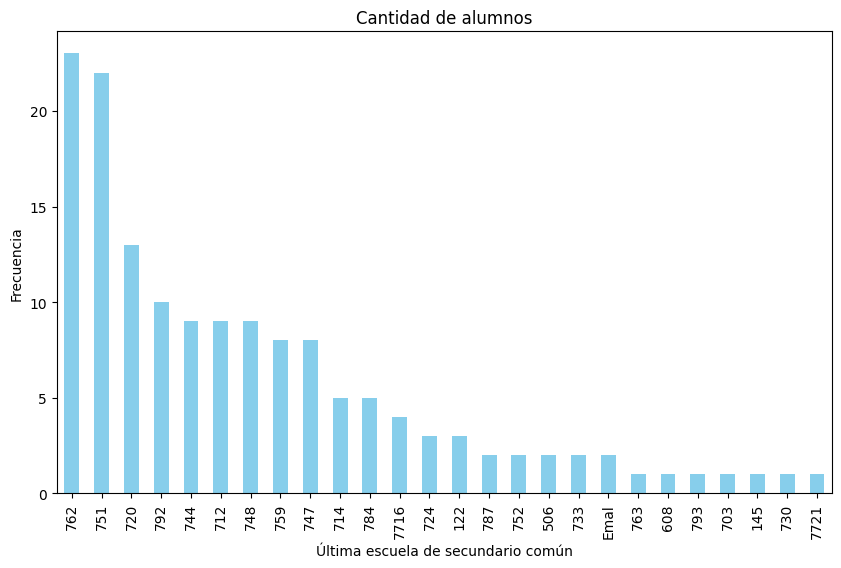

In [ ]:
# Cuento la frecuencia de cada ítem
item_counts = datos['Última escuela común'].value_counts()

# Grafico la frecuencia de ítems
plt.figure(figsize=(10,6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de alumnos')
plt.xlabel('Última escuela de secundario común')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()


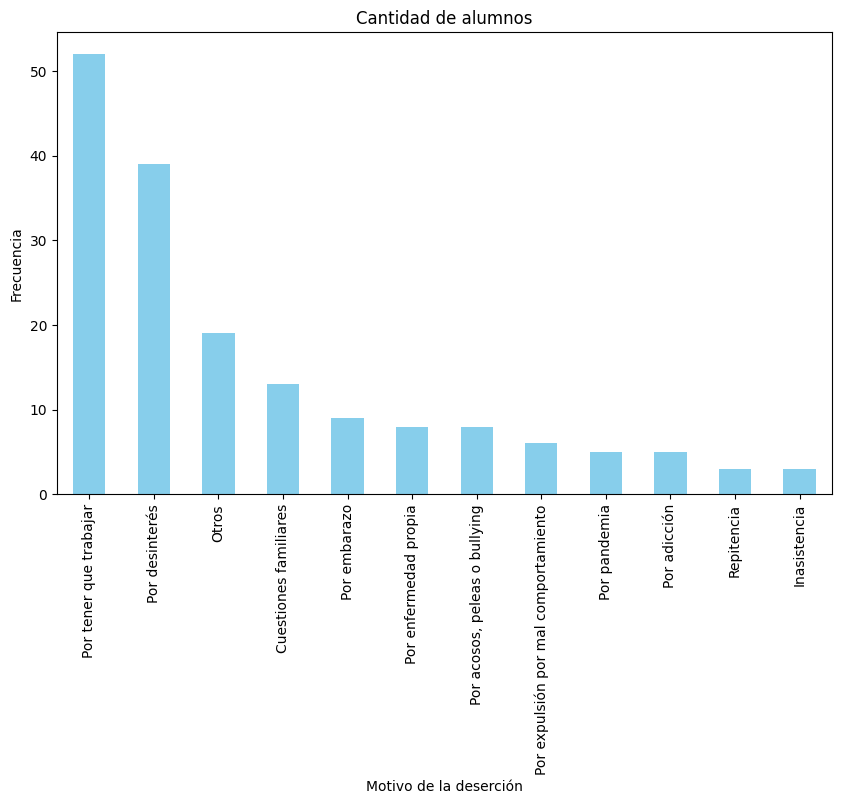

In [ ]:
# Cuento la frecuencia de cada ítem
item_counts = datos['Motivo de abandono'].value_counts()

# Grafico la frecuencia de ítems
plt.figure(figsize=(10,6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de alumnos')
plt.xlabel('Motivo de la deserción')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()


Se observa que el principal motivo de deserción escolar es la necesidad de trabajar, seguido por la falta de interés en los estudios.

En menor medida, aparecen factores como cuestiones familiares, embarazo y problemas de salud, lo que indica que la deserción es un fenómeno multifactorial.

Estos resultados sugieren que, además de intervenciones pedagógicas, es fundamental considerar el contexto socioeconómico de los estudiantes al diseñar estrategias de retención escolar.

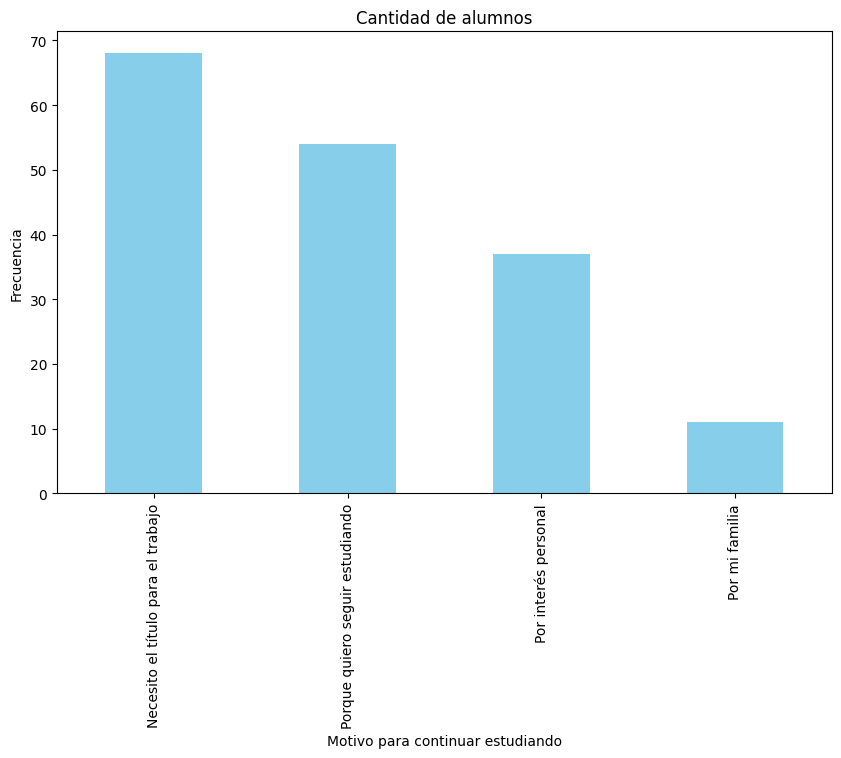

In [ ]:
# Cuento la frecuencia de cada ítem
item_counts = datos['Motivo para seguir estudiando'].value_counts()

# Grafico la frecuencia de ítems
plt.figure(figsize=(10,6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de alumnos')
plt.xlabel('Motivo para continuar estudiando')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

Se observa que el principal motivo para continuar estudiando es la necesidad de obtener un título para acceder a mejores oportunidades laborales, seguido por el interés en continuar aprendiendo.

En menor medida, aparecen factores como el interés personal y el acompañamiento familiar, lo que sugiere que tanto motivaciones extrínsecas (laborales) como intrínsecas (personales) influyen en la permanencia escolar.

Estos resultados destacan la importancia de fortalecer el vínculo entre educación y oportunidades laborales, así como de fomentar el interés y la motivación de los estudiantes como estrategias clave para mejorar la retención.

In [ ]:
# Veo valores únicos de la columna
valores_unicos = datos["Edad"].unique()
print(valores_unicos)

# Cuento cuántas veces aparece cada uno
conteo = datos["Edad"].value_counts()
print(conteo)

[22 39 18 21 19 42  5 24 55 30 46 29 20 26 16 69 23 17 35 48 63 45 50 40
 38 54 34 77 33 56 25 68 49 28 32 41 36 51 31 37 27 57]
Edad
20    16
24    13
21    11
19     9
23     9
22     9
18     8
28     7
35     6
39     5
26     5
46     5
25     5
29     5
31     4
33     4
30     4
42     3
34     3
36     3
37     3
27     3
40     3
54     3
51     2
5      2
48     2
69     2
45     2
50     2
55     1
63     1
16     1
17     1
38     1
68     1
77     1
56     1
49     1
41     1
32     1
57     1
Name: count, dtype: int64


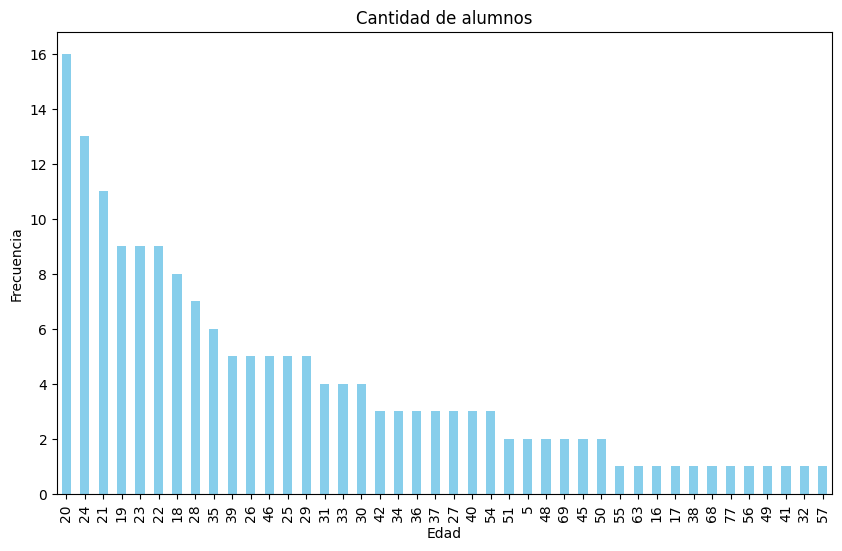

In [ ]:
# Cuento la frecuencia de cada ítem
item_counts = datos['Edad'].value_counts()

# Grafico la frecuencia de ítems
plt.figure(figsize=(10,6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de alumnos')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()


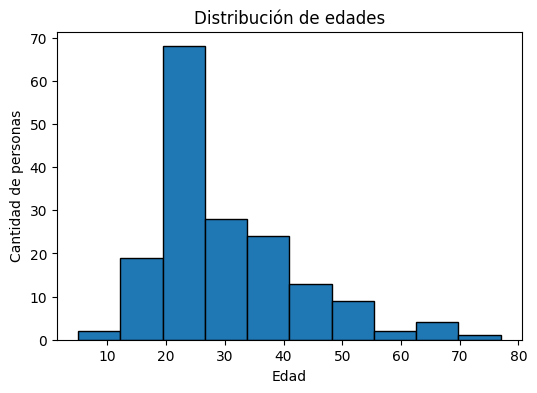

In [ ]:
# Gráfico de distribución
plt.figure(figsize=(6,4))
plt.hist(datos['Edad'].dropna(), bins=10, edgecolor='black')
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad de personas")
plt.show()

La distribución de edades muestra una mayor concentración de estudiantes en rangos entre los 20 y 30 años, aunque también se observa la presencia de adultos de mayor edad.

Este dato permite interpretar que muchos estudiantes combinan sus estudios con responsabilidades laborales y personales, lo que se vincula directamente con los principales motivos de deserción identificados, como la necesidad de trabajar.

En este sentido, la edad y el contexto de vida de los estudiantes resultan factores relevantes para comprender tanto la deserción como la permanencia en el sistema educativo.

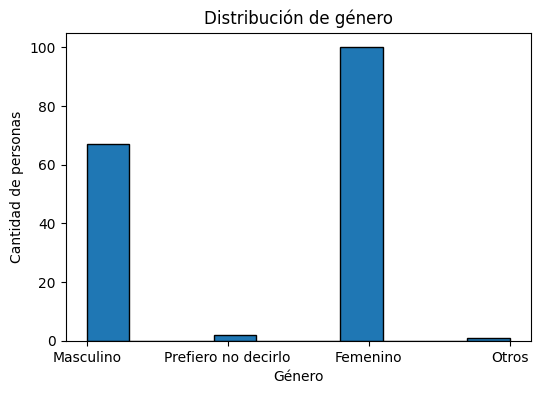

In [ ]:
# Gráfico de distribución
plt.figure(figsize=(6,4))
plt.hist(datos['Género'].dropna(), bins=10, edgecolor='black')
plt.title("Distribución de género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.show()

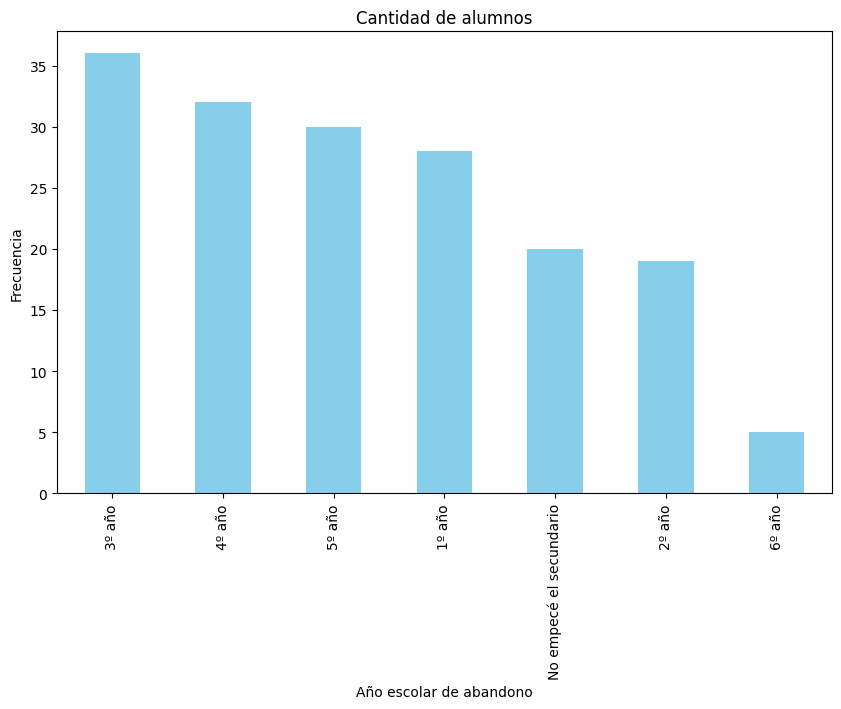

In [ ]:
# Cuento la frecuencia de cada ítem
item_counts = datos['Año escolar de abandono'].value_counts()

# Grafico la frecuencia de ítems
plt.figure(figsize=(10,6))
item_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de alumnos')
plt.xlabel('Año escolar de abandono')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

Se observa que el tercer año presenta los niveles más altos de deserción en comparación con otros niveles.

Este patrón podría indicar que se trata de un momento crítico en la trayectoria escolar de los estudiantes, por lo que resulta clave focalizar estrategias de acompañamiento y retención en este nivel.

# Transformación de los datos objet

In [ ]:
# Obtenenemos todos los valores únicos (sin duplicados) de la columna
datos['Género'].unique()


array(['Masculino', 'Prefiero no decirlo', 'Femenino', 'Otros'],
      dtype=object)

In [ ]:
#Convierto los valores categóricos (como texto) en valores numéricos de forma automática
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
datos['Género']= le.fit_transform(datos['Género'])
datos['Género'].unique()

array([1, 3, 0, 2])

In [ ]:
datos['Año de abandono'].unique()

array([2018, 2023, 2024, 2021, 1999, 2014,    0, 1990, 2012, 2019, 2009,
       1995, 2022, 2017, 1970, 2020, 2010, 2006, 1964, 1992, 1988, 2001,
       1986, 1989, 2015, 2918, 2016, 1994, 2011, 2008, 2005, 1983, 2007,
       1991, 2013, 2003, 2000, 2002, 2004, 1998, 1997, 1982])

In [ ]:
le = LabelEncoder()
datos['Año de abandono']= le.fit_transform(datos['Año de abandono'])
datos['Año de abandono'].unique()

array([34, 39, 40, 37, 15, 30,  0,  8, 28, 35, 25, 12, 38, 33,  2, 36, 26,
       22,  1, 10,  6, 17,  5,  7, 31, 41, 32, 11, 27, 24, 21,  4, 23,  9,
       29, 19, 16, 18, 20, 14, 13,  3])

In [ ]:
# Lista de columnas a codificar
columnas_a_codificar = [
    "Edad",
    "Año de abandono",
    "Última escuela común",
    "Nivel",
    "Ciudad",
    "Año escolar de abandono",
    "Motivo de abandono",
    "Motivo para seguir estudiando"
]

# Creamos una instancia de LabelEncoder
le = LabelEncoder()

# Aplicamos la codificación a cada columna
for col in columnas_a_codificar:
    datos[col] = le.fit_transform(datos[col].astype(str))

# Verificar valores codificados de una columna de ejemplo
print(datos["Edad"].unique())


[ 6 23  2  5  3 26 31  8 35 14 28 13  4 10  0 40  7  1 19 29 38 27 32 24
 22 34 18 41 17 36  9 39 30 12 16 25 20 33 15 21 11 37]


In [ ]:
datos.head()

,Edad,Género,Año de abandono,Última escuela común,Nivel,Ciudad,Año escolar de abandono,Motivo de abandono,Motivo para seguir estudiando
0,6,1,28,21,1,13,0,5,0
1,23,3,33,26,0,17,6,2,0
2,2,1,35,6,1,13,4,8,0
3,5,1,28,5,1,13,1,10,3
4,3,1,31,17,1,14,2,9,1


#Escalado de datos

In [ ]:
# Escalo los datos
scaler = StandardScaler()
datos_scaled = scaler.fit_transform(datos)

In [ ]:
datos_scaled_df = pd.DataFrame(datos_scaled, columns=datos.columns)
datos_scaled_df.head()

,Edad,Género,Año de abandono,Última escuela común,Nivel,Ciudad,Año escolar de abandono,Motivo de abandono,Motivo para seguir estudiando
0,-0.746356,0.974423,0.422989,0.874493,0.222915,0.139134,-1.446698,-0.322185,-1.013495
1,0.880317,4.461832,0.872415,1.595461,-2.692132,1.770359,1.817975,-1.205597,-1.013495
2,-1.129102,0.974423,1.052186,-1.288413,0.222915,0.139134,0.729750,0.561226,-1.013495
3,-0.842042,0.974423,0.422989,-1.432607,0.222915,0.139134,-0.902586,1.150167,1.325340
4,-1.033416,0.974423,0.692645,0.297718,0.222915,0.546940,-0.358474,0.855696,-0.233883


In [ ]:
# Calculo la matriz de covarianza de los datos escalados
covariance_matrix = pd.DataFrame(datos_scaled_df).cov()
covariance_matrix.head()

# Interpretacion de la matriz:
      #Si la covarianza es positiva: las dos variables tienden a aumentar juntas.
      #Si la covarianza es negativa: cuando una aumenta, la otra tiende a disminuir.
      #Si la covarianza es cero: las variables no tienen relación lineal

,Edad,Género,Año de abandono,Última escuela común,Nivel,Ciudad,Año escolar de abandono,Motivo de abandono,Motivo para seguir estudiando
Edad,1.005917,-0.070096,-0.445003,0.242622,-0.273319,0.097069,0.038324,-0.101003,-0.028603
Género,-0.070096,1.005917,0.101961,0.038463,-0.038038,-0.010148,0.036987,0.072740,0.044241
Año de abandono,-0.445003,0.101961,1.005917,0.008991,0.156318,-0.035992,0.140084,0.072717,0.036074
Última escuela común,0.242622,0.038463,0.008991,1.005917,-0.293091,-0.040624,0.071144,0.045485,0.002195
Nivel,-0.273319,-0.038038,0.156318,-0.293091,1.005917,0.179827,-0.463964,0.011294,0.025550


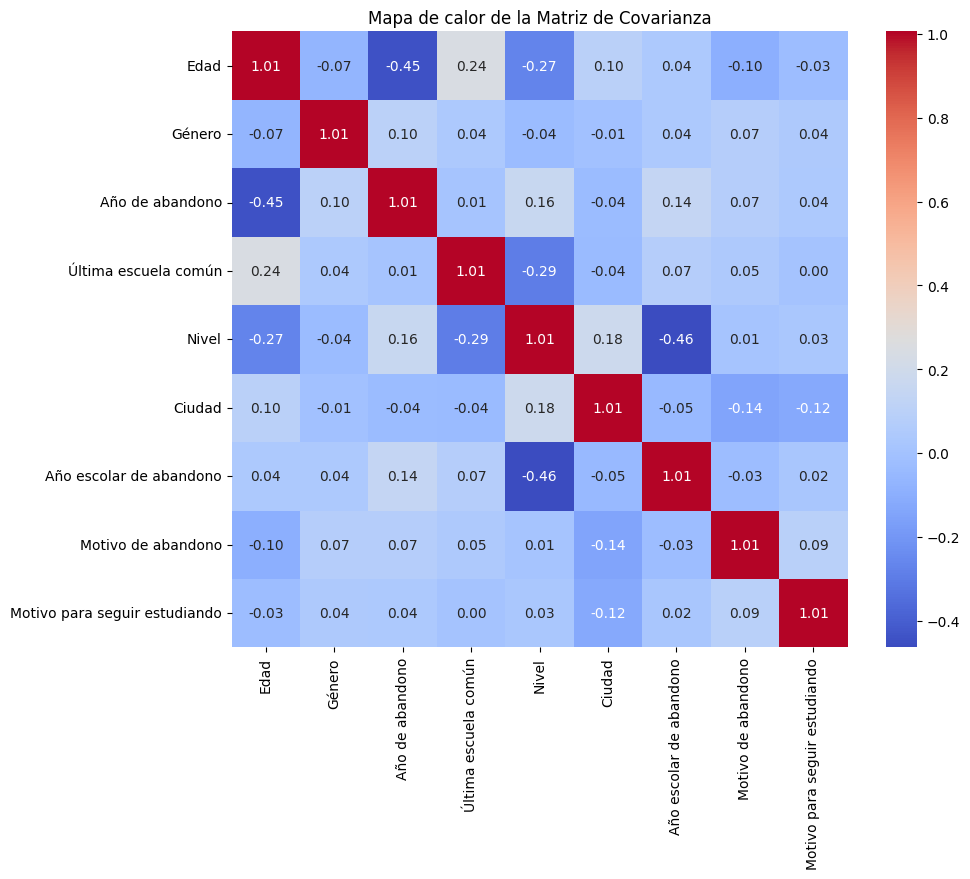

In [ ]:
# Mapa de calor con los datos escalados

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)

plt.title("Mapa de calor de la Matriz de Covarianza")
plt.show()

Conclusiones

A partir del análisis realizado, se identificaron diversos factores que presentan relación con la deserción escolar. Entre los principales hallazgos se destaca la influencia de variables como la asistencia, el rendimiento académico y otras condiciones asociadas al contexto del estudiante.

Los resultados muestran que ciertos patrones pueden utilizarse como indicadores tempranos de riesgo de abandono, lo cual resulta relevante para instituciones educativas que buscan mejorar la retención de sus estudiantes.

Este tipo de análisis permite transformar datos en información útil para la toma de decisiones, facilitando el diseño de estrategias de intervención más efectivas.

Como línea futura, este trabajo podría complementarse con modelos predictivos que permitan anticipar la deserción y actuar de manera preventiva.